# PART 4

Haikal Ali_1103223071_TK46GAB

# Membangun Model dengan Distance Metrics dan Nearest Neighbors

Notebook ini dibuat berdasarkan materi **Building Models with Distance Metrics and Nearest Neighbors**.

Materi utama:
- pengantar distance metrics,
- konsep K-Nearest Neighbors (KNN),
- perbandingan Euclidean, Manhattan, dan Minkowski distance,
- implementasi KNN dengan scikit-learn,
- tuning hyperparameter KNN,
- evaluasi performa KNN.

Bagian yang memiliki contoh kode dibuat sebagai cell kode. Bagian yang tidak memiliki kode dibuat sebagai teori saja.

## 1. Kebutuhan Teknis

Materi menyarankan penggunaan environment Python yang terisolasi agar pekerjaan tidak bercampur dengan instalasi atau library Python lain.

Kebutuhan teknis yang disebutkan:
- Git >= 2.46.x
- Python >= 3.9.x
- repository GitHub sudah di-clone
- environment Python dibuat dari file `requirements.txt`

## 2. Pengantar Distance Metrics

Distance metrics adalah cara untuk mengukur kemiripan atau perbedaan antar titik data di dalam feature space. Konsep ini penting dalam machine learning, terutama untuk tugas seperti klasifikasi, regresi, dan clustering.

Dalam konteks machine learning, data point yang dekat biasanya dianggap memiliki karakteristik yang mirip. Karena itu, pemilihan distance metric dapat memengaruhi hasil model.

Tiga distance metric yang dibahas:

1. **Euclidean distance**  
   Mengukur jarak garis lurus antar titik dalam ruang berdimensi n. Ini adalah distance metric yang paling umum digunakan.

2. **Manhattan distance**  
   Mengukur jarak berdasarkan jumlah selisih absolut antar koordinat. Analogi sederhananya seperti bergerak di kota berbentuk grid, hanya bisa horizontal dan vertikal.

3. **Minkowski distance**  
   Generalisasi dari Euclidean dan Manhattan distance. Parameter `p` menentukan bentuk pengukuran jaraknya. Jika `p=1`, hasilnya seperti Manhattan distance. Jika `p=2`, hasilnya seperti Euclidean distance.

## 3. Memahami K-Nearest Neighbors (KNN)

KNN adalah algoritma supervised learning yang dapat digunakan untuk klasifikasi dan regresi. Ide dasarnya sederhana: sebuah data baru diprediksi berdasarkan data-data terdekat yang sudah memiliki label.

Jika digunakan untuk klasifikasi, KNN melihat mayoritas label dari tetangga terdekat. Jika digunakan untuk regresi, KNN biasanya menghitung rata-rata nilai dari tetangga terdekat.

Pada contoh ini digunakan dataset **Iris** dari scikit-learn. Dataset dipisahkan menjadi data latih dan data uji menggunakan `train_test_split()`.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load dataset iris
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=2024
)

### Implementasi KNN Dasar

scikit-learn menyediakan `KNeighborsClassifier` untuk membuat model KNN klasifikasi. Pada contoh ini, jumlah tetangga yang digunakan adalah `n_neighbors=3`.

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Membuat dan melatih model KNN dasar
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Membuat prediksi
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


### Cara Kerja KNN

KNN bekerja dengan prinsip berikut:

- **Memilih k**: nilai `k` menentukan jumlah tetangga terdekat yang dipakai untuk membuat prediksi.
- **Menghitung jarak**: jarak antar titik dihitung menggunakan distance metric, misalnya Euclidean, Manhattan, atau Minkowski.
- **Voting mechanism**: untuk klasifikasi, label dipilih berdasarkan mayoritas label dari tetangga terdekat.

Nilai `k` yang terlalu kecil dapat membuat model sensitif terhadap noise. Nilai `k` yang terlalu besar dapat membuat model terlalu halus dan mengabaikan pola lokal.

### Pemilihan Nilai k dan Distance Metric

Pemilihan nilai `k` penting untuk performa KNN. Strategi yang disebutkan dalam materi:

- **Cross-validation**: mengevaluasi model pada beberapa nilai `k` untuk mencari nilai yang paling baik.
- **Elbow method**: membuat plot performa terhadap berbagai nilai `k`, lalu mencari titik ketika peningkatan performa mulai melambat.

Distance metric juga perlu dipilih sesuai karakteristik data. Euclidean distance sering menjadi pilihan default, tetapi Manhattan atau metric lain dapat memberi hasil lebih baik untuk struktur data tertentu.

## 4. Distance Metrics Overview

Bagian ini membandingkan beberapa distance metric pada dua dataset sintetis:

1. **Noisy circles dataset**  
   Dataset berbentuk lingkaran dengan noise.

2. **Checkerboard dataset**  
   Dataset berbentuk grid untuk memperlihatkan perbedaan dampak distance metric.

Dataset ini bersifat ilustratif untuk memahami pengaruh metric terhadap performa KNN.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Membuat dua dataset sintetis
n_samples = 300

# Circular dataset dengan noise tinggi
X_circles, y_circles = make_circles(
  n_samples=n_samples,
  noise=0.3, factor=0.3
)
X_circles_train, X_circles_test,   y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles,
    test_size=0.2, random_state=2024
)

# Checkerboard pattern dataset
x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test,   y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons,
    test_size=0.2, random_state=2024
)

### Membandingkan Distance Metrics

Distance metric yang dibandingkan:
- `euclidean`
- `manhattan`
- `minkowski`

Setiap metric digunakan untuk melatih KNN pada dua dataset, lalu hasilnya dibandingkan menggunakan accuracy.

In [4]:
# Membandingkan distance metrics pada kedua dataset
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
  # Test pada circles dataset
  knn_circles = KNeighborsClassifier(
    n_neighbors=3,
    metric=metric
  )
  knn_circles.fit(X_circles_train, y_circles_train)
  y_pred_circles = knn_circles.predict(X_circles_test)
  results['circles'][metric] = accuracy_score(
    y_circles_test, y_pred_circles
  )

  # Test pada moons/checkerboard dataset
  knn_moons = KNeighborsClassifier(
    n_neighbors=3,
    metric=metric
  )
  knn_moons.fit(X_moons_train, y_moons_train)
  y_pred_moons = knn_moons.predict(X_moons_test)
  results['moons'][metric] = accuracy_score(
    y_moons_test, y_pred_moons
  )

results

{'circles': {'euclidean': 0.9333333333333333,
  'manhattan': 0.9166666666666666,
  'minkowski': 0.9333333333333333},
 'moons': {'euclidean': 0.8103448275862069,
  'manhattan': 0.8448275862068966,
  'minkowski': 0.8103448275862069}}

### Visualisasi Perbandingan Distance Metrics

Visualisasi berikut menampilkan data latih dan data uji, serta accuracy dari setiap distance metric pada masing-masing dataset.

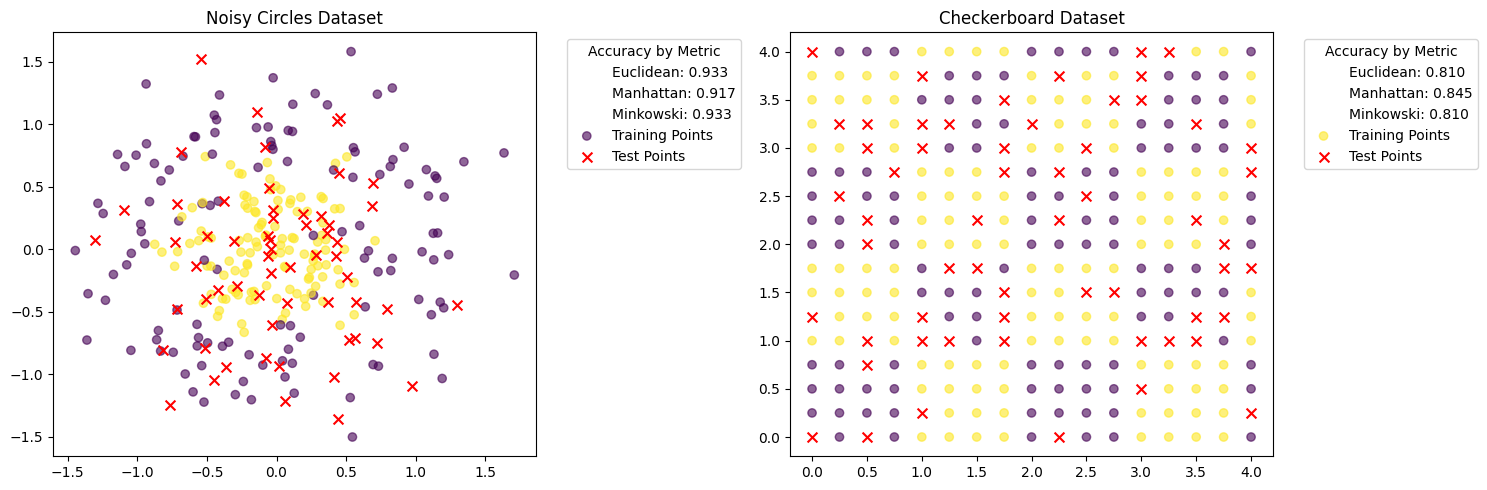

In [5]:
# Set up plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot circles dataset
scatter1_train = ax1.scatter(
  X_circles_train[:, 0], X_circles_train[:, 1],
  c=y_circles_train, cmap='viridis',
  alpha=0.6, label='Training Points'
)
scatter1_test = ax1.scatter(
  X_circles_test[:, 0], X_circles_test[:, 1],
  color='red', marker='x', s=50,
  label='Test Points'
)
ax1.set_title('Noisy Circles Dataset')

# Dummy lines untuk legend
lines1 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text1 = [
  f"Euclidean: {results['circles']['euclidean']:.3f}",
  f"Manhattan: {results['circles']['manhattan']:.3f}",
  f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(
  lines1 + [scatter1_train, scatter1_test],
  legend_text1 + ['Training Points', 'Test Points'],
  title='Accuracy by Metric',
  bbox_to_anchor=(1.05, 1),
  loc='upper left'
)

# Plot moons/checkerboard dataset
scatter2_train = ax2.scatter(
  X_moons_train[:, 0], X_moons_train[:, 1],
  c=y_moons_train, cmap='viridis',
  alpha=0.6, label='Training Points'
)
scatter2_test = ax2.scatter(
  X_moons_test[:, 0], X_moons_test[:, 1],
  color='red', marker='x', s=50,
  label='Test Points'
)
ax2.set_title('Checkerboard Dataset')

# Dummy lines untuk legend
lines2 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text2 = [
  f"Euclidean: {results['moons']['euclidean']:.3f}",
  f"Manhattan: {results['moons']['manhattan']:.3f}",
  f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(
  lines2 + [scatter2_train, scatter2_test],
  legend_text2 + ['Training Points', 'Test Points'],
  title='Accuracy by Metric',
  bbox_to_anchor=(1.05, 1),
  loc='upper left'
)

plt.tight_layout()
plt.show()

### Ringkasan Distance Metrics

Tiga distance metric yang paling umum dibahas:

- **Euclidean distance**: menghitung jarak garis lurus. Metric ini umum digunakan pada KNN, tetapi sensitif terhadap outlier dan skala fitur.
- **Manhattan distance**: menghitung jumlah selisih absolut antar koordinat. Metric ini juga disebut L1 distance atau city block distance.
- **Minkowski distance**: generalisasi dari Euclidean dan Manhattan distance. Parameter `p` dapat mengubah sifat perhitungan jaraknya.

Pemilihan distance metric dapat memengaruhi performa model karena setiap metric membaca jarak antar titik dengan cara berbeda.

### Dampak Distance Metric terhadap Performa Model

Hal yang perlu diperhatikan:

- **Sensitivity to scale**: Euclidean distance sangat dipengaruhi oleh skala fitur, sehingga standardisasi atau normalisasi fitur penting sebelum memakai KNN.
- **Dimensionality effects**: pada ruang berdimensi tinggi, jarak antar data point bisa menjadi kurang bermakna. Ini berkaitan dengan masalah curse of dimensionality.

Strategi yang disarankan:

- pahami jenis data yang digunakan,
- coba beberapa distance metric,
- gunakan cross-validation untuk mengevaluasi metric secara sistematis.

## 5. Hyperparameter Tuning pada KNN

Hyperparameter adalah nilai yang mengatur bagaimana model belajar. Berbeda dengan parameter model yang dipelajari selama training, hyperparameter ditentukan sebelum atau selama proses pencarian konfigurasi model.

Pada KNN, hyperparameter yang dituning dalam materi ini adalah:

- `n_neighbors`: jumlah tetangga terdekat,
- `weights`: cara memberi bobot pada tetangga,
- `metric`: distance metric yang digunakan.

Teknik tuning yang digunakan adalah **GridSearchCV**.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Membuat classifier KNN
knn = KNeighborsClassifier()

# Mendefinisikan hyperparameter grid
param_grid = {
  'n_neighbors': [3, 5, 7, 9, 11],
  'weights': ['uniform', 'distance'],
  'metric': ['euclidean', 'manhattan']
}

# Membuat grid search
grid_search = GridSearchCV(
  knn, param_grid, cv=5, scoring='accuracy'
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Print parameter dan score terbaik
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668


### Cara Kerja Grid Search

Grid search mencoba seluruh kombinasi hyperparameter yang sudah ditentukan dalam `param_grid`. Kombinasi yang memberikan performa terbaik akan dipilih.

Cross-validation digunakan agar evaluasi model tidak hanya bergantung pada satu pembagian data. Dengan cara ini, performa model menjadi lebih dapat dipercaya.

Selain grid search, materi juga menyebutkan **RandomizedSearchCV**. Teknik ini mengambil kombinasi parameter secara acak dari ruang pencarian, sehingga dapat lebih hemat waktu ketika jumlah kombinasi parameter sangat besar. Bagian ini hanya teori karena tidak ada contoh kode RandomizedSearchCV pada materi.

## 6. Evaluasi Performa KNN

Evaluasi performa model penting untuk memahami seberapa baik model membuat prediksi dan bagian mana yang masih perlu diperbaiki.

Pada materi ini, evaluasi dilakukan menggunakan:

- cross-validation scores,
- learning curves,
- confusion matrix,
- classification report.

In [7]:
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from IPython.display import display

### Cross-Validation Scores

Cross-validation scores digunakan untuk melihat performa model pada beberapa subset data latih.

In [8]:
# Cross-validation scores dari estimator terbaik hasil grid search
cv_scores = cross_val_score(
  grid_search.best_estimator_,
  X_train, y_train, cv=5
)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9916666666666668
Standard deviation: 0.016666666666666653


### Learning Curves

Learning curve menunjukkan hubungan antara jumlah data latih dan performa model. Visualisasi ini dapat membantu melihat apakah model mengalami underfitting atau overfitting.

In [9]:
# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
  grid_search.best_estimator_,
  X_train, y_train,
  train_sizes=np.linspace(0.1, 1.0, 10),
  cv=5
)

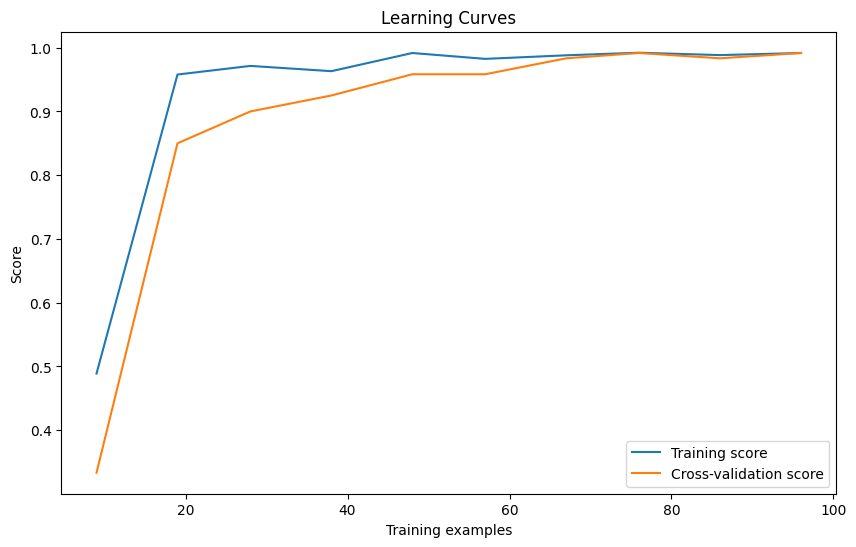

In [10]:
# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(
  train_sizes,
  np.mean(train_scores, axis=1),
  label='Training score'
)
plt.plot(
  train_sizes,
  np.mean(test_scores, axis=1),
  label='Cross-validation score'
)
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.show()

### Confusion Matrix

Confusion matrix memberikan ringkasan prediksi model. Nilai pada diagonal menunjukkan prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan prediksi yang salah.

In [11]:
# Prediksi pada test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Nama kelas dari dataset iris
class_names = iris.target_names

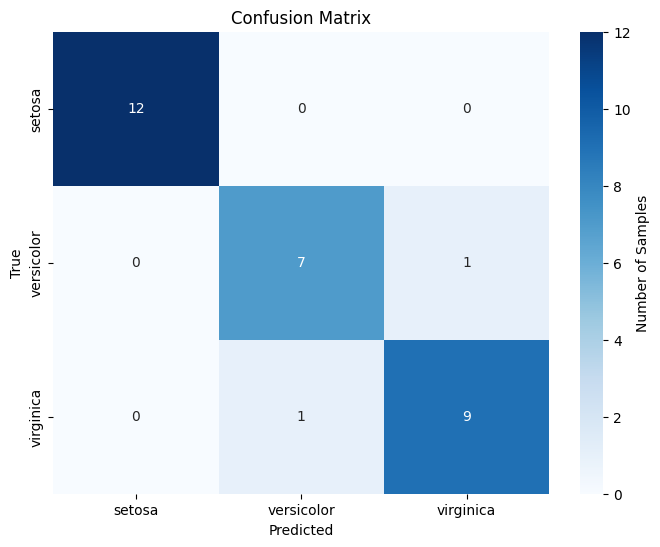

In [12]:
# Generate dan plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
  cm, annot=True, fmt='d', cmap='Blues',
  xticklabels=class_names,
  yticklabels=class_names,
  cbar_kws={'label': 'Number of Samples'}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

Classification report menampilkan beberapa metrik performa dalam satu tabel, seperti precision, recall, f1-score, dan support.

In [13]:
# Classification report sebagai dictionary
report_dict = classification_report(
  y_test, y_pred,
  target_names=class_names,
  output_dict=True
)

In [14]:
# Membuat DataFrame agar lebih mudah dibaca
report_df = pd.DataFrame(report_dict).transpose()

# Style DataFrame
styled_df = (
  report_df
  .style
  .background_gradient(
    cmap='Blues', subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print("\nClassification Report:")
display(styled_df)


Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


### Metrik Evaluasi yang Dibahas

Metrik yang disebutkan dalam materi:

- **Learning curves**: menunjukkan performa model terhadap ukuran data latih.
- **Confusion matrix**: menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.
- **Precision**: mengukur ketepatan prediksi positif.
- **Recall**: mengukur kemampuan model menemukan instance yang relevan.
- **F1-score**: harmonic mean dari precision dan recall.
- **Accuracy**: rasio jumlah prediksi benar terhadap seluruh prediksi.
- **Macro average**: rata-rata metrik dari seluruh label.
- **Weighted average**: rata-rata metrik dari seluruh label dengan mempertimbangkan jumlah data pada setiap label.

Materi juga menekankan bahwa skor tinggi belum tentu cukup untuk menyimpulkan model bagus dalam kasus nyata. Performa model tetap harus dilihat berdasarkan masalah bisnis atau konteks yang sedang dimodelkan.

### Imbalanced Dataset

Jika dataset memiliki distribusi kelas yang tidak seimbang, accuracy saja dapat menyesatkan. Materi menyarankan beberapa hal:

- gunakan metrik seperti precision-recall curve atau ROC-AUC, bukan hanya accuracy,
- gunakan teknik resampling, seperti oversampling pada kelas minoritas atau undersampling pada kelas mayoritas.

## 7. Practical Exercises dengan KNN Models

Bagian akhir materi berisi latihan praktis untuk membangun, melakukan tuning, dan mengevaluasi model KNN. Tidak ada kode lengkap pada bagian ini, sehingga ditulis sebagai teori dan langkah kerja.

### Exercise 1: Building a KNN Classifier

Langkah implementasi:

1. Load libraries.
2. Load dataset.
3. Preprocess data.
4. Create and train KNN classifier.
5. Make predictions.
6. Evaluate performance.

### Exercise 2: Tuning Hyperparameters with Grid Search

Langkah implementasi:

1. Load libraries.
2. Load different dataset.
3. Preprocess data.
4. Set up grid search.
5. Fit grid search.
6. Evaluate best model.

### Exercise 3: Evaluating a KNN Classifier

Langkah implementasi:

1. Load libraries.
2. Load dataset.
3. Preprocess data.
4. Create and train KNN classifier.
5. Make predictions.
6. Evaluate performance.

## 8. Catatan Akhir

Setelah memahami implementasi dasar KNN, materi menyebutkan bahwa distance metrics juga dapat dicoba untuk tugas machine learning lain seperti clustering dan regression.

Materi juga menyebutkan beberapa teknik lanjutan yang tersedia di scikit-learn, seperti:

- DBSCAN,
- mean shift,
- spectral clustering,
- kernel density,
- radius neighbors classifier.

Bagian ini hanya berupa teori karena tidak ada contoh kode implementasi pada materi.